<a href="https://colab.research.google.com/github/jyeon6273/DeepNeuralNetworks/blob/main/street_food_kaggle_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Street Food Image Classification — ResNet-18 Kaggle Assignment

This notebook provides a complete baseline for the **Street Food Image Classification** Kaggle competition.

### Pipeline
1. Inspect the Kaggle input files
2. Load and visualize the dataset
3. Create a stratified train/validation split
4. Apply image augmentation
5. Fine-tune **ResNet-18**
6. Train for **10 epochs**
7. Evaluate validation accuracy
8. Load the best checkpoint
9. Predict the Kaggle test set
10. Create `submission.csv`

**Model:** ResNet-18  
**Epochs:** 10  
**Metric:** Accuracy  
**Input size:** 224 × 224

> Recommended Kaggle setting: **GPU T4 x2 / P100 / T4** if available.


In [ ]:
!unzip -o street-food-image-classification.zip

Archive:  street-food-image-classification.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: test_images/00de5019.jpg  
  inflating: test_images/013d2855.jpg  
  inflating: test_images/02edbdf7.jpg  
  inflating: test_images/03139344.jpg  
  inflating: test_images/03413ef9.jpg  
  inflating: test_images/03c8ab9f.jpg  
  inflating: test_images/040c6ace.jpg  
  inflating: test_images/0418dd73.jpg  
  inflating: test_images/041df2da.jpg  
  inflating: test_images/0436ad53.jpg  
  inflating: test_images/043919c0.jpg  
  inflating: test_images/045a3f9e.jpg  
  inflating: test_images/047581c6.jpg  
  inflating: test_images/04862e59.jpg  
  inflating: test_images/04be01f3.jpg  
  inflating: test_images/05022981.jpg  
  inflating: test_images/052bea5c.jpg  
  inflating: test_images/05328ff0.jpg  
  inflating: test_images/05787d61.jpg  
  inflating: test_images/057a3510.jpg  
  inflating: test_images/05f39776.jpg  
  inflating: test_images/061bb3ed.jpg

In [ ]:

# ============================================================
# 1. IMPORTS AND REPRODUCIBILITY
# ============================================================

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4



## 2. Locate the competition data


In [ ]:
# ============================================================
# 2. DATA PATH
# ============================================================

from pathlib import Path

# Change this only if your folder has a different name
DATA_ROOT = Path("/content/")

print("DATA_ROOT =", DATA_ROOT)

# Check files/folders
print("\nDataset contents:")
for item in DATA_ROOT.iterdir():
    print(" -", item.name)

DATA_ROOT = /content

Dataset contents:
 - .config
 - sample_submission.csv
 - test.csv
 - train.csv
 - test_images
 - street-food-image-classification.zip
 - train_images
 - sample_data


In [ ]:

# ============================================================
# 3. CONFIGURATION
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
EPOCHS = 10
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
VAL_SIZE = 0.20

# Use ImageNet-pretrained ResNet-18 when available.
# If pretrained weights cannot be downloaded/cached, the notebook
# automatically falls back to randomly initialized ResNet-18.
USE_PRETRAINED = True

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

print({
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "validation_fraction": VAL_SIZE,
})


{'image_size': 224, 'batch_size': 32, 'epochs': 10, 'learning_rate': 0.0003, 'validation_fraction': 0.2}



## 4. Automatically detect the dataset format

The notebook supports the two most common Kaggle image-classification layouts:

### A. CSV labels
```text
train.csv
sample_submission.csv
train_images/
test_images/
```

### B. Class folders
```text
train/
    class_1/
    class_2/
    ...
test/
    image_001.jpg
    image_002.jpg
```

This keeps the notebook usable even if Kaggle changes folder names slightly.


In [ ]:

# ============================================================
# 4. DATASET HELPERS
# ============================================================

def image_files_under(root):
    if root is None or not Path(root).exists():
        return []
    return [
        p for p in Path(root).rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

def find_csv(root, kind):
    csvs = list(Path(root).rglob("*.csv"))
    kind = kind.lower()

    if kind == "sample":
        matches = [p for p in csvs if "sample" in p.name.lower() and "submission" in p.name.lower()]
    elif kind == "train":
        matches = [p for p in csvs if "train" in p.name.lower() and "submission" not in p.name.lower()]
    elif kind == "test":
        matches = [p for p in csvs if "test" in p.name.lower() and "submission" not in p.name.lower()]
    else:
        matches = []

    return sorted(matches, key=lambda p: (len(p.parts), len(p.name)))[0] if matches else None

def find_named_dir(root, names):
    names = {n.lower() for n in names}
    dirs = [p for p in Path(root).rglob("*") if p.is_dir() and p.name.lower() in names]
    if not dirs:
        return None

    # Prefer shallower paths with more images
    dirs = sorted(
        dirs,
        key=lambda p: (len(p.relative_to(root).parts), -len(image_files_under(p)))
    )
    return dirs[0]

def looks_like_imagefolder(path):
    if path is None or not Path(path).exists():
        return False
    subdirs = [p for p in Path(path).iterdir() if p.is_dir()]
    if len(subdirs) < 2:
        return False
    class_dirs_with_images = sum(len(image_files_under(d)) > 0 for d in subdirs)
    return class_dirs_with_images >= 2

SAMPLE_SUB_PATH = find_csv(DATA_ROOT, "sample")
TRAIN_CSV_PATH = find_csv(DATA_ROOT, "train")
TEST_CSV_PATH = find_csv(DATA_ROOT, "test")

TRAIN_DIR = find_named_dir(
    DATA_ROOT,
    {"train", "training", "train_images", "training_images"}
)
TEST_DIR = find_named_dir(
    DATA_ROOT,
    {"test", "testing", "test_images", "testing_images"}
)

print("TRAIN_CSV_PATH :", TRAIN_CSV_PATH)
print("TEST_CSV_PATH  :", TEST_CSV_PATH)
print("SAMPLE_SUB_PATH:", SAMPLE_SUB_PATH)
print("TRAIN_DIR      :", TRAIN_DIR)
print("TEST_DIR       :", TEST_DIR)
print("ImageFolder training structure:", looks_like_imagefolder(TRAIN_DIR))


TRAIN_CSV_PATH : /content/train.csv
TEST_CSV_PATH  : /content/test.csv
SAMPLE_SUB_PATH: /content/sample_submission.csv
TRAIN_DIR      : /content/train_images
TEST_DIR       : /content/test_images
ImageFolder training structure: True


In [ ]:

# ============================================================
# 5. IMAGE TRANSFORMS
# ============================================================

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.05,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


In [ ]:

# ============================================================
# 6. GENERIC CSV-BASED IMAGE DATASET
# ============================================================

def infer_columns(df):
    cols = list(df.columns)
    lower = {c.lower(): c for c in cols}

    # Image/file/id column
    image_candidates = [
        "image", "image_name", "imagename", "filename", "file_name",
        "file", "filepath", "path", "id", "image_id"
    ]
    image_col = next((lower[c] for c in image_candidates if c in lower), None)

    if image_col is None:
        # Prefer a string-like column
        string_cols = [
            c for c in cols
            if df[c].dtype == "object" or pd.api.types.is_string_dtype(df[c])
        ]
        image_col = string_cols[0] if string_cols else cols[0]

    # Label column
    label_candidates = ["label", "class", "category", "target", "food", "food_class"]
    label_col = next((lower[c] for c in label_candidates if c in lower and lower[c] != image_col), None)

    if label_col is None:
        remaining = [c for c in cols if c != image_col]
        # A classification label usually has relatively few unique values
        if remaining:
            label_col = min(remaining, key=lambda c: df[c].nunique(dropna=False))

    return image_col, label_col


def build_image_index(root):
    files = image_files_under(root)
    by_name = {}
    by_stem = {}

    for p in files:
        by_name.setdefault(p.name, p)
        by_name.setdefault(p.name.lower(), p)
        by_stem.setdefault(p.stem, p)
        by_stem.setdefault(p.stem.lower(), p)

    return files, by_name, by_stem


def resolve_image(value, search_root, by_name, by_stem):
    value = str(value)

    # 1) Exact relative path
    direct = Path(search_root) / value
    if direct.exists():
        return direct

    # 2) Exact basename
    name = Path(value).name
    if name in by_name:
        return by_name[name]
    if name.lower() in by_name:
        return by_name[name.lower()]

    # 3) Stem only
    stem = Path(value).stem
    if stem in by_stem:
        return by_stem[stem]
    if stem.lower() in by_stem:
        return by_stem[stem.lower()]

    raise FileNotFoundError(f"Could not find image for value: {value}")


class CSVImageDataset(Dataset):
    def __init__(self, df, image_col, image_paths, transform=None, targets=None):
        self.df = df.reset_index(drop=True)
        self.image_col = image_col
        self.image_paths = list(image_paths)
        self.transform = transform
        self.targets = None if targets is None else np.asarray(targets, dtype=np.int64)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        if self.targets is None:
            return img

        return img, int(self.targets[idx])


In [ ]:

# ============================================================
# 7. BUILD TRAIN / VALIDATION DATASETS
# ============================================================

label_encoder = None
train_mode = None

if TRAIN_CSV_PATH is not None:
    # ---------- CSV MODE ----------
    train_mode = "csv"
    train_df = pd.read_csv(TRAIN_CSV_PATH)

    image_col, label_col = infer_columns(train_df)

    if label_col is None:
        raise ValueError(
            f"Could not infer the label column from {TRAIN_CSV_PATH}. "
            f"Columns: {list(train_df.columns)}"
        )

    print("Training CSV shape:", train_df.shape)
    print("Image column:", image_col)
    print("Label column:", label_col)
    display(train_df.head())

    # Prefer TRAIN_DIR if found; otherwise search the full competition root
    train_search_root = TRAIN_DIR if TRAIN_DIR is not None else DATA_ROOT
    _, train_by_name, train_by_stem = build_image_index(train_search_root)

    train_paths = [
        resolve_image(v, train_search_root, train_by_name, train_by_stem)
        for v in train_df[image_col]
    ]

    label_encoder = LabelEncoder()
    y_all = label_encoder.fit_transform(train_df[label_col].astype(str))
    class_names = list(label_encoder.classes_)
    num_classes = len(class_names)

    train_idx, val_idx = train_test_split(
        np.arange(len(train_df)),
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=y_all,
    )

    train_ds_full = CSVImageDataset(
        train_df, image_col, train_paths, transform=train_transform, targets=y_all
    )
    val_ds_full = CSVImageDataset(
        train_df, image_col, train_paths, transform=val_test_transform, targets=y_all
    )

    train_dataset = Subset(train_ds_full, train_idx)
    val_dataset = Subset(val_ds_full, val_idx)

else:
    # ---------- IMAGEFOLDER MODE ----------
    train_mode = "imagefolder"

    if not looks_like_imagefolder(TRAIN_DIR):
        raise FileNotFoundError(
            "No usable train.csv was found and the detected training directory "
            "does not appear to contain one subfolder per class."
        )

    base_train = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
    base_val = datasets.ImageFolder(TRAIN_DIR, transform=val_test_transform)

    class_names = base_train.classes
    num_classes = len(class_names)
    y_all = np.asarray(base_train.targets)

    train_idx, val_idx = train_test_split(
        np.arange(len(base_train)),
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=y_all,
    )

    train_dataset = Subset(base_train, train_idx)
    val_dataset = Subset(base_val, val_idx)

print("\nTraining mode:", train_mode)
print("Number of classes:", num_classes)
print("Classes:", class_names)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))


Training CSV shape: (1520, 2)
Image column: image_id
Label column: label


,image_id,label
0,burger/0003_burger.jpg,burger
1,burger/0004_burger.jpg,burger
2,burger/0005_burger.jpg,burger
3,burger/0007_burger.jpg,burger
4,burger/0008_burger.jpg,burger



Training mode: csv
Number of classes: 10
Classes: ['burger', 'churros', 'crepes', 'falafel', 'hot_dog', 'pad_thai', 'pani_puri', 'pretzel', 'shawarma', 'tacos']
Training samples: 1216
Validation samples: 304


,class_index,class_name,count
1,1,churros,160
2,2,crepes,160
4,4,hot_dog,160
8,8,shawarma,159
9,9,tacos,158
0,0,burger,156
6,6,pani_puri,155
7,7,pretzel,143
3,3,falafel,141
5,5,pad_thai,128


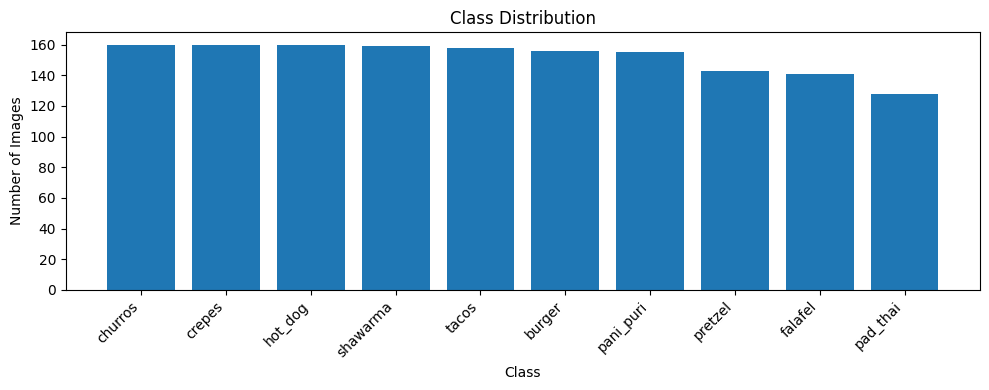

In [ ]:

# ============================================================
# 8. CLASS DISTRIBUTION
# ============================================================

unique, counts = np.unique(y_all, return_counts=True)

dist_df = pd.DataFrame({
    "class_index": unique,
    "class_name": [class_names[i] for i in unique],
    "count": counts
}).sort_values("count", ascending=False)

display(dist_df)

plt.figure(figsize=(10, 4))
plt.bar(dist_df["class_name"], dist_df["count"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:

# ============================================================
# 9. DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))


Train batches: 38
Validation batches: 10


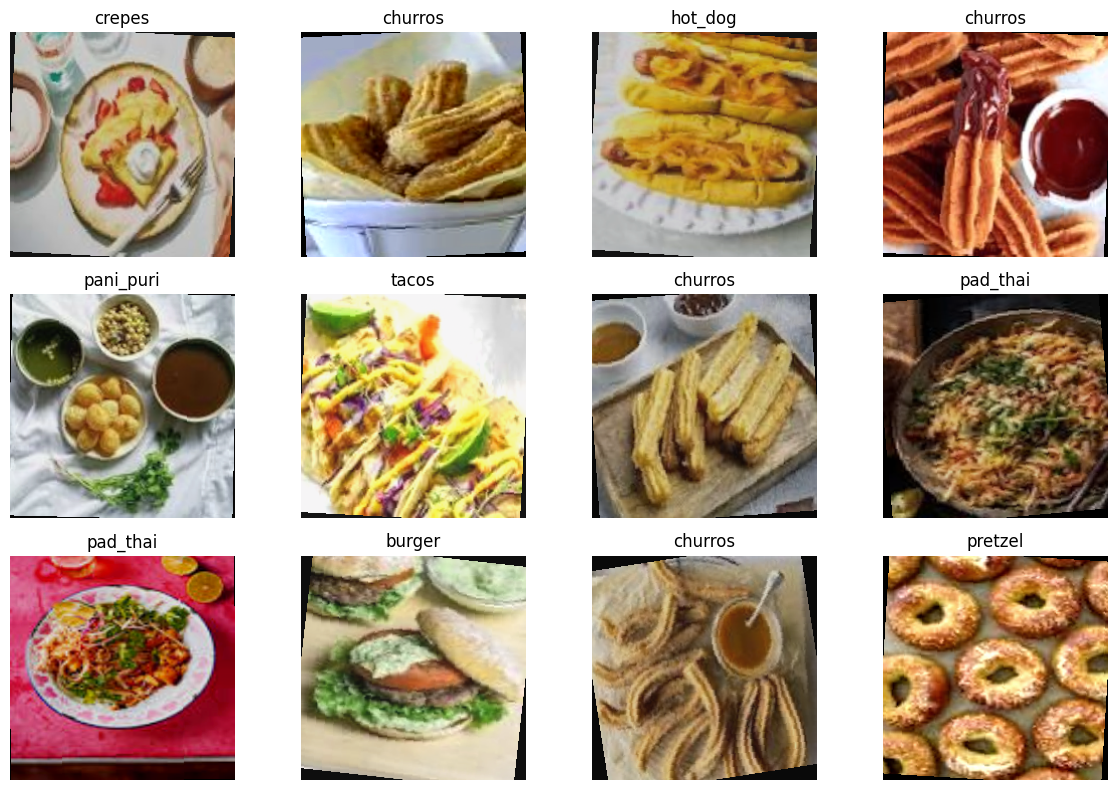

In [ ]:

# ============================================================
# 10. VISUALIZE A TRAINING BATCH
# ============================================================

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(img.cpu() * std + mean, 0, 1)

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))
for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(denormalize(images[i]).permute(1, 2, 0))
    plt.title(class_names[int(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()



## 11. Build ResNet-18

We replace the original 1000-class ImageNet classifier with a new fully connected layer whose output size equals the number of classes in this competition.

All layers are fine-tuned.


In [ ]:
# ============================================================
# MODEL
# ============================================================

# ResNet-18 pretrained on ImageNet
model = models.resnet18(weights="DEFAULT")

# Change the final layer for our dataset
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(DEVICE)


# ============================================================
# OTHER MODEL OPTIONS
# ============================================================

# VGG-16
# model = models.vgg16(weights="DEFAULT")
# model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
# model = model.to(DEVICE)


# MobileNet-V2
# model = models.mobilenet_v2(weights="DEFAULT")
# model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
# model = model.to(DEVICE)


# DenseNet-121
# model = models.densenet121(weights="DEFAULT")
# model.classifier = nn.Linear(model.classifier.in_features, num_classes)
# model = model.to(DEVICE)


# EfficientNet-B0
# model = models.efficientnet_b0(weights="DEFAULT")
# model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
# model = model.to(DEVICE)


# ============================================================
# LOSS AND OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 217MB/s]

Linear(in_features=512, out_features=10, bias=True)


In [ ]:

# ============================================================
# 12. TRAINING AND VALIDATION FUNCTIONS
# ============================================================

USE_AMP = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_targets = []
    all_predictions = []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

        all_targets.extend(labels.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

    return (
        total_loss / total_samples,
        total_correct / total_samples,
        np.array(all_targets),
        np.array(all_predictions),
    )


In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = 0.0

for epoch in range(EPOCHS):

    # Train
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    # Validate
    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        criterion
    )

    # Save results
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet18.pth")

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}%"
    )

print("\nBest Validation Accuracy:",
      f"{best_val_acc*100:.2f}%")

Epoch [1/10] Train Loss: 1.0325 | Train Acc: 65.38% | Val Loss: 1.2486 | Val Acc: 57.57%
Epoch [2/10] Train Loss: 0.8106 | Train Acc: 71.05% | Val Loss: 1.1808 | Val Acc: 57.24%
Epoch [3/10] Train Loss: 0.6866 | Train Acc: 77.14% | Val Loss: 1.4339 | Val Acc: 63.16%
Epoch [4/10] Train Loss: 0.6040 | Train Acc: 79.19% | Val Loss: 1.1551 | Val Acc: 62.17%
Epoch [5/10] Train Loss: 0.5658 | Train Acc: 81.17% | Val Loss: 1.2730 | Val Acc: 62.83%
Epoch [6/10] Train Loss: 0.5094 | Train Acc: 82.73% | Val Loss: 0.9992 | Val Acc: 70.72%
Epoch [7/10] Train Loss: 0.4518 | Train Acc: 84.05% | Val Loss: 1.3527 | Val Acc: 62.83%
Epoch [8/10] Train Loss: 0.3461 | Train Acc: 88.82% | Val Loss: 1.1016 | Val Acc: 67.11%
Epoch [9/10] Train Loss: 0.2590 | Train Acc: 91.04% | Val Loss: 1.0765 | Val Acc: 71.71%
Epoch [10/10] Train Loss: 0.3340 | Train Acc: 89.14% | Val Loss: 1.2169 | Val Acc: 67.76%

Best Validation Accuracy: 71.71%


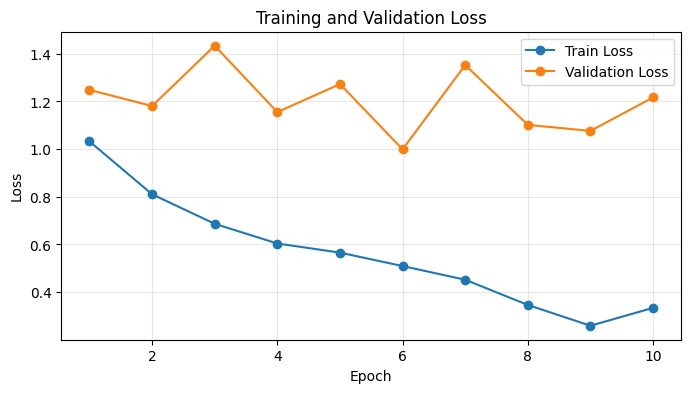

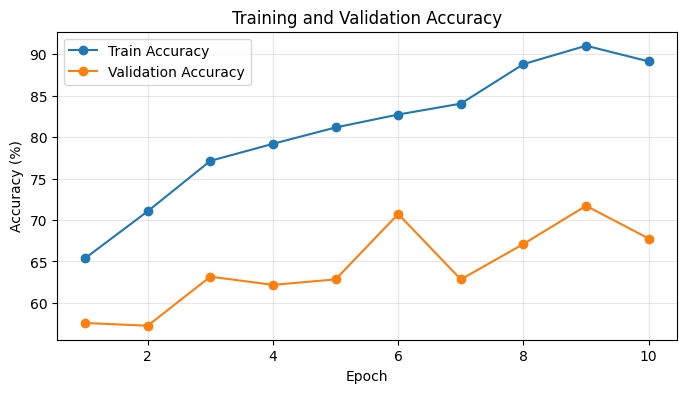

In [ ]:

# ============================================================
# 14. TRAINING CURVES
# ============================================================

epochs_axis = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_axis, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_axis, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_axis, np.array(history["train_acc"]) * 100, marker="o", label="Train Accuracy")
plt.plot(epochs_axis, np.array(history["val_acc"]) * 100, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# ============================================================
# LOAD BEST MODEL AND EVALUATE
# ============================================================

# Load the best saved model
model.load_state_dict(
    torch.load("best_resnet18.pth", map_location=DEVICE)
)

# Evaluate on validation set
val_loss, val_acc, val_targets, val_preds = evaluate(
    model,
    val_loader,
    criterion
)

print(f"Validation Accuracy: {val_acc * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        val_targets,
        val_preds,
        target_names=class_names,
        zero_division=0
    )
)

Validation Accuracy: 71.71%

Classification Report:
              precision    recall  f1-score   support

      burger       1.00      0.94      0.97        31
     churros       0.77      0.75      0.76        32
      crepes       0.71      0.69      0.70        32
     falafel       0.77      0.82      0.79        28
     hot_dog       0.66      0.59      0.62        32
    pad_thai       0.81      0.81      0.81        26
   pani_puri       0.88      0.71      0.79        31
     pretzel       0.74      0.82      0.78        28
    shawarma       0.56      0.31      0.40        32
       tacos       0.46      0.78      0.58        32

    accuracy                           0.72       304
   macro avg       0.74      0.72      0.72       304
weighted avg       0.73      0.72      0.72       304



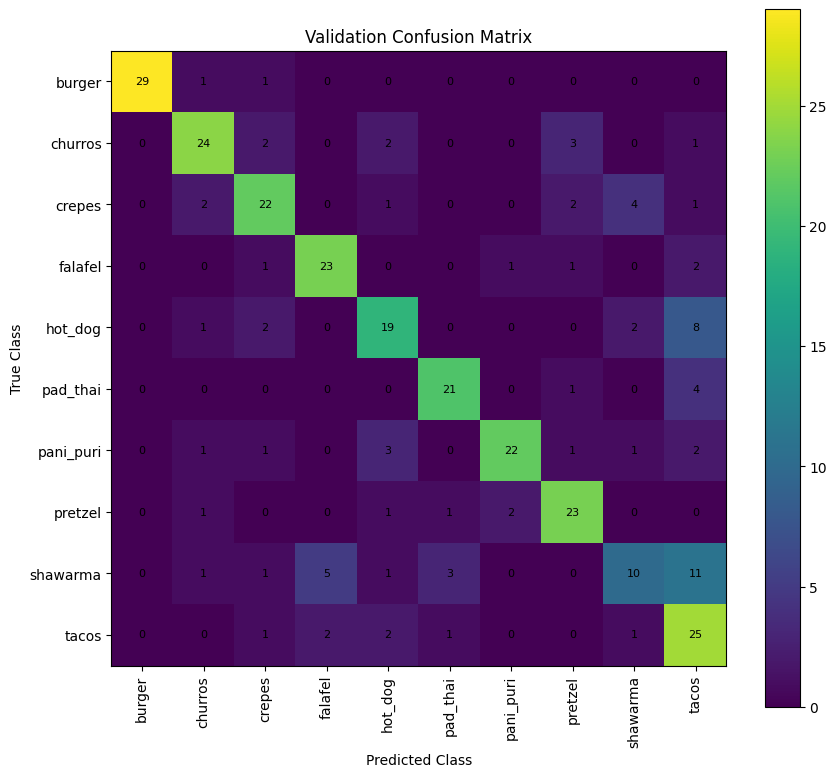

In [ ]:

# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    val_targets,
    val_preds,
    labels=list(range(num_classes)),
)

plt.figure(figsize=(9, 8))
plt.imshow(cm)
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

plt.colorbar()
plt.tight_layout()
plt.show()



## 17. Prepare the Kaggle test set

For submission, the notebook uses `sample_submission.csv` as the template whenever it is available. This is the safest way to preserve the required row order and column names.


In [ ]:

# ============================================================
# 17. BUILD TEST DATASET IN SUBMISSION ORDER
# ============================================================

class TestImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = list(image_paths)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img


test_search_root = TEST_DIR if TEST_DIR is not None else DATA_ROOT
test_files, test_by_name, test_by_stem = build_image_index(test_search_root)

if SAMPLE_SUB_PATH is not None:
    sample_submission = pd.read_csv(SAMPLE_SUB_PATH)
    print("Sample submission:")
    display(sample_submission.head())
    print("Columns:", list(sample_submission.columns))

    # For a standard single-label classification submission, the first
    # column is normally the image/file/id column.
    submission_id_col = sample_submission.columns[0]
    target_cols = list(sample_submission.columns[1:])

    if len(target_cols) == 0:
        raise ValueError("sample_submission.csv has no prediction column.")

    test_paths = [
        resolve_image(v, test_search_root, test_by_name, test_by_stem)
        for v in sample_submission[submission_id_col]
    ]

else:
    sample_submission = None
    submission_id_col = "image"
    target_cols = ["label"]
    test_paths = sorted(test_files)

    if not test_paths:
        raise FileNotFoundError("No test images were found.")

print("Number of test images:", len(test_paths))

test_dataset = TestImageDataset(
    test_paths,
    transform=val_test_transform,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


Sample submission:


,image_id,label
0,caa537b8.jpg,burger
1,0d335021.jpg,burger
2,135fbbcb.jpg,burger
3,45bf117b.jpg,burger
4,a42f665f.jpg,burger


Columns: ['image_id', 'label']
Number of test images: 764


In [ ]:

# ============================================================
# 18. TEST PREDICTIONS
# ============================================================

@torch.no_grad()
def predict(model, loader):
    model.eval()

    all_pred_indices = []
    all_probs = []

    for images in loader:
        images = images.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        all_pred_indices.extend(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    return np.array(all_pred_indices), np.concatenate(all_probs, axis=0)


test_pred_indices, test_probs = predict(model, test_loader)

if label_encoder is not None:
    test_pred_labels = label_encoder.inverse_transform(test_pred_indices)
else:
    test_pred_labels = np.array([class_names[i] for i in test_pred_indices])

print("First 20 predicted labels:")
print(test_pred_labels[:20])


First 20 predicted labels:
['burger' 'burger' 'burger' 'burger' 'burger' 'burger' 'falafel' 'falafel'
 'burger' 'burger' 'burger' 'burger' 'burger' 'burger' 'hot_dog' 'hot_dog'
 'burger' 'burger' 'burger' 'burger']


In [ ]:

# ============================================================
# 19. CREATE submission.csv
# ============================================================

SUBMISSION_PATH = "your_id_submission.csv"

if sample_submission is not None:
    submission = sample_submission.copy()

    if len(target_cols) == 1:
        # Standard format: image/id column + one class-label column
        submission[target_cols[0]] = test_pred_labels

    elif len(target_cols) == num_classes:
        # Optional support for probability-column submissions
        # where each target column represents one class.
        target_name_to_index = {str(name): i for i, name in enumerate(class_names)}

        if all(str(c) in target_name_to_index for c in target_cols):
            for col in target_cols:
                submission[col] = test_probs[:, target_name_to_index[str(col)]]
        else:
            raise ValueError(
                "The sample submission contains multiple prediction columns, "
                "but they do not match the detected class names."
            )
    else:
        raise ValueError(
            f"Unexpected submission format. Prediction columns: {target_cols}"
        )

else:
    submission = pd.DataFrame({
        submission_id_col: [p.name for p in test_paths],
        target_cols[0]: test_pred_labels,
    })

submission.to_csv(SUBMISSION_PATH, index=False)

print("Saved:", SUBMISSION_PATH)
print("Submission shape:", submission.shape)
display(submission.head(10))


Saved: your_id_submission.csv
Submission shape: (764, 2)


,image_id,label
0,caa537b8.jpg,burger
1,0d335021.jpg,burger
2,135fbbcb.jpg,burger
3,45bf117b.jpg,burger
4,a42f665f.jpg,burger
5,d4136b39.jpg,burger
6,e0a69e22.jpg,falafel
7,6ff269eb.jpg,falafel
8,5203a82d.jpg,burger
9,d6f85446.jpg,burger


In [ ]:

# ============================================================
# 20. FINAL SUBMISSION CHECKS
# ============================================================

assert len(submission) == len(test_paths), "Submission row count does not match test set."
assert not submission.isna().any().any(), "Submission contains missing values."

if len(target_cols) == 1:
    print("Predicted class counts:")
    display(submission[target_cols[0]].value_counts())

print("\nSubmission file is ready:")
print(SUBMISSION_PATH)
print("\nIn Kaggle, open the notebook Output/Files section and submit submission.csv.")


Predicted class counts:


,count
label,
tacos,136
hot_dog,92
crepes,76
burger,76
falafel,74
churros,74
pretzel,72
pani_puri,60
pad_thai,60



Submission file is ready:
your_id_submission.csv

In Kaggle, open the notebook Output/Files section and submit submission.csv.
